# RAG Experiment Results — Key Metrics Visualization

Analysis of **216 RAG pipeline experiments** across varying parameters.  
Primary metrics: **Grounding pass rate** and **Relevance pass rate** (out of 40 questions each).

**Varying parameters:**
- `generator_model`: phi4:14b, qwen2.5:7b, mistral:7b, gemma2:9b, llama3.2:3b, qwen2.5:0.5b
- `retrieval_strategy`: dense, bm25, hybrid
- `embedding_model`: MiniLM-L6, mpnet-base, bge-large
- `reranker`: none, cross-encoder
- `k`: 3, 5

*(chunk_size=500, chunk_overlap=100, temperature=0.0 are constant across all experiments)*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('experiment_results_summary.csv')

# Derived metrics
df['grounding_rate'] = df['grounding_passes'] / df['total_questions'] * 100
df['relevance_rate'] = df['relevance_passes'] / df['total_questions'] * 100

# Short labels for embedding models
emb_labels = {
    'sentence-transformers/all-MiniLM-L6-v2': 'MiniLM-L6',
    'sentence-transformers/all-mpnet-base-v2': 'mpnet-base',
    'BAAI/bge-large-en-v1.5': 'bge-large'
}
df['emb_short'] = df['embedding_model'].map(emb_labels)

print(f'Loaded {len(df)} experiments')
df[['generator_model','retrieval_strategy','emb_short','reranker','k',
    'grounding_rate','relevance_rate','mean_grounding_score','mean_relevance_score']].describe()

Loaded 216 experiments


,k,grounding_rate,relevance_rate,mean_grounding_score,mean_relevance_score
count,216.000000,216.000000,216.000000,216.000000,216.000000
mean,4.000000,71.018519,47.858796,0.646565,0.626727
std,1.002323,8.820148,10.986978,0.076316,0.071511
min,3.000000,45.000000,17.500000,0.455000,0.478000
25%,3.000000,65.000000,40.000000,0.590000,0.562000
50%,4.000000,72.500000,50.000000,0.662000,0.625000
75%,5.000000,77.500000,57.500000,0.703000,0.685000
max,5.000000,87.500000,70.000000,0.786000,0.770000


## 1. Overall Distribution of Pass Rates

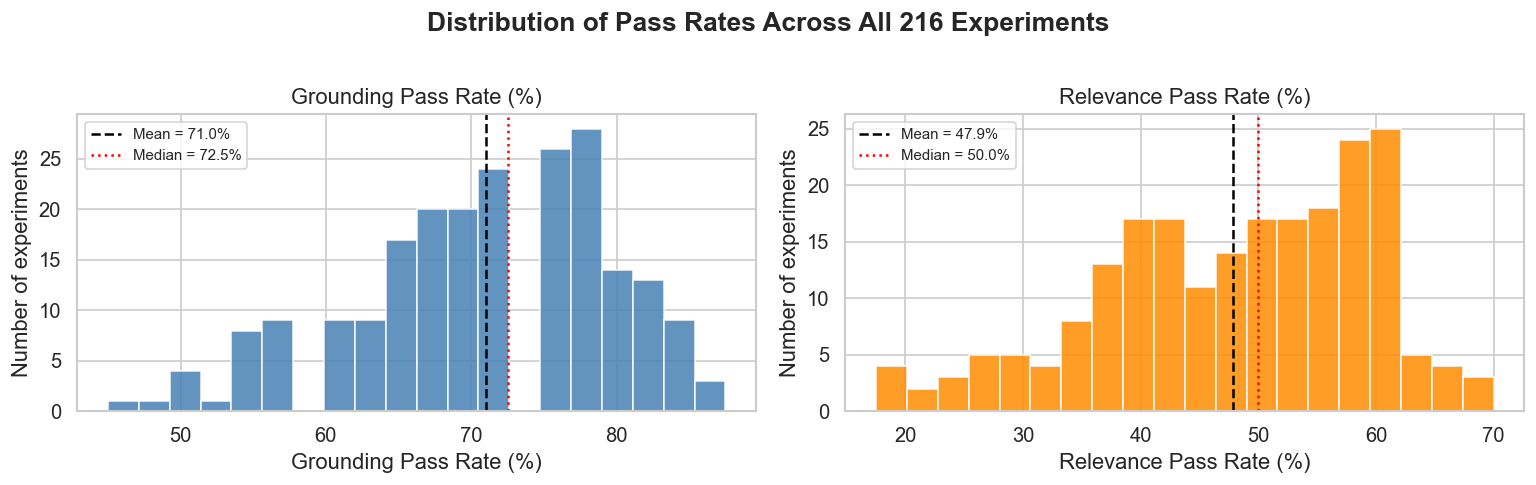

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, color, label in zip(
    axes,
    ['grounding_rate', 'relevance_rate'],
    ['steelblue', 'darkorange'],
    ['Grounding Pass Rate (%)', 'Relevance Pass Rate (%)']
):
    ax.hist(df[col], bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='black', linewidth=1.5, linestyle='--',
               label=f'Mean = {df[col].mean():.1f}%')
    ax.axvline(df[col].median(), color='red', linewidth=1.5, linestyle=':',
               label=f'Median = {df[col].median():.1f}%')
    ax.set_xlabel(label)
    ax.set_ylabel('Number of experiments')
    ax.set_title(label)
    ax.legend(fontsize=9)

fig.suptitle('Distribution of Pass Rates Across All 216 Experiments', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 2. Effect of Generator Model

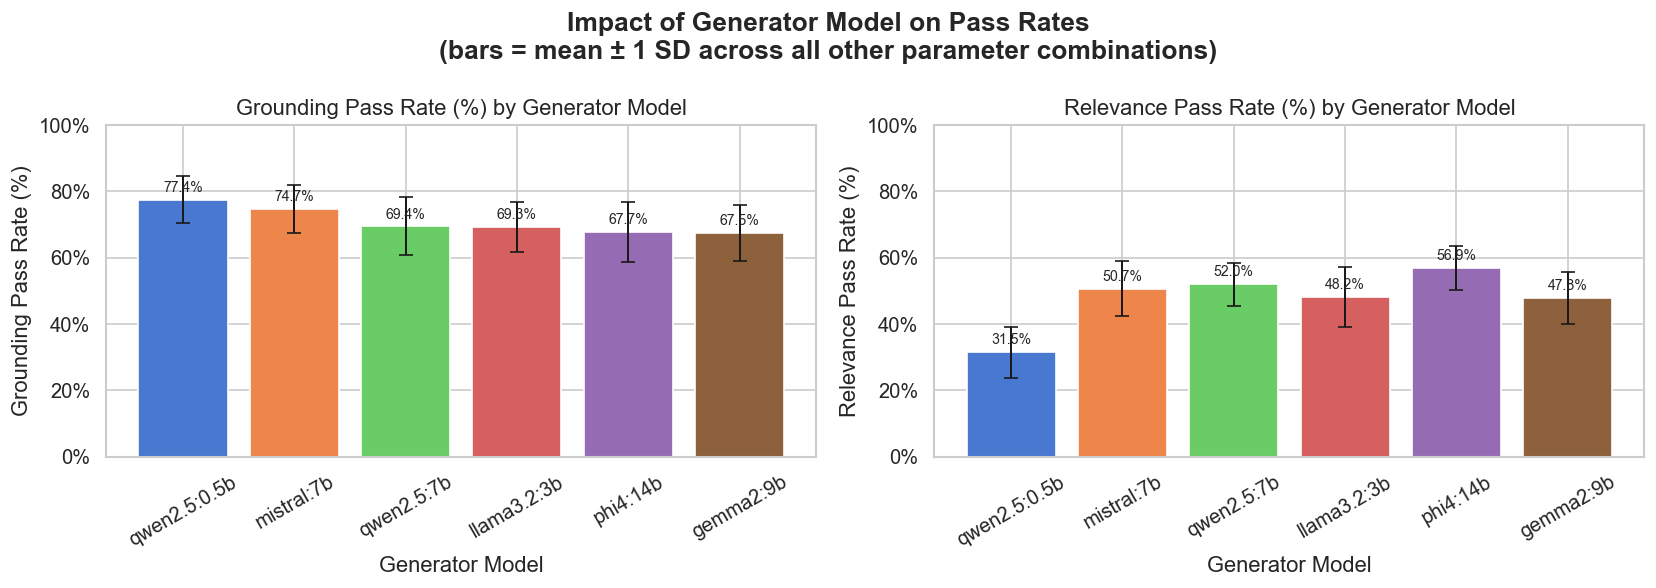

In [3]:
# Order models by grounding rate
model_order = (df.groupby('generator_model')['grounding_rate']
               .mean().sort_values(ascending=False).index)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, metric, title in zip(
    axes,
    ['grounding_rate', 'relevance_rate'],
    ['Grounding Pass Rate (%)', 'Relevance Pass Rate (%)']
):
    agg = (df.groupby('generator_model')[metric]
           .agg(['mean', 'std'])
           .reindex(model_order)
           .reset_index())
    colors = sns.color_palette('muted', len(agg))
    bars = ax.bar(agg['generator_model'], agg['mean'],
                  yerr=agg['std'], capsize=4,
                  color=colors, edgecolor='white', error_kw={'linewidth':1.2})
    ax.set_xlabel('Generator Model')
    ax.set_ylabel(title)
    ax.set_title(f'{title} by Generator Model')
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))
    for bar, val in zip(bars, agg['mean']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=8.5)

fig.suptitle('Impact of Generator Model on Pass Rates\n(bars = mean ± 1 SD across all other parameter combinations)',
             fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Effect of Retrieval Strategy

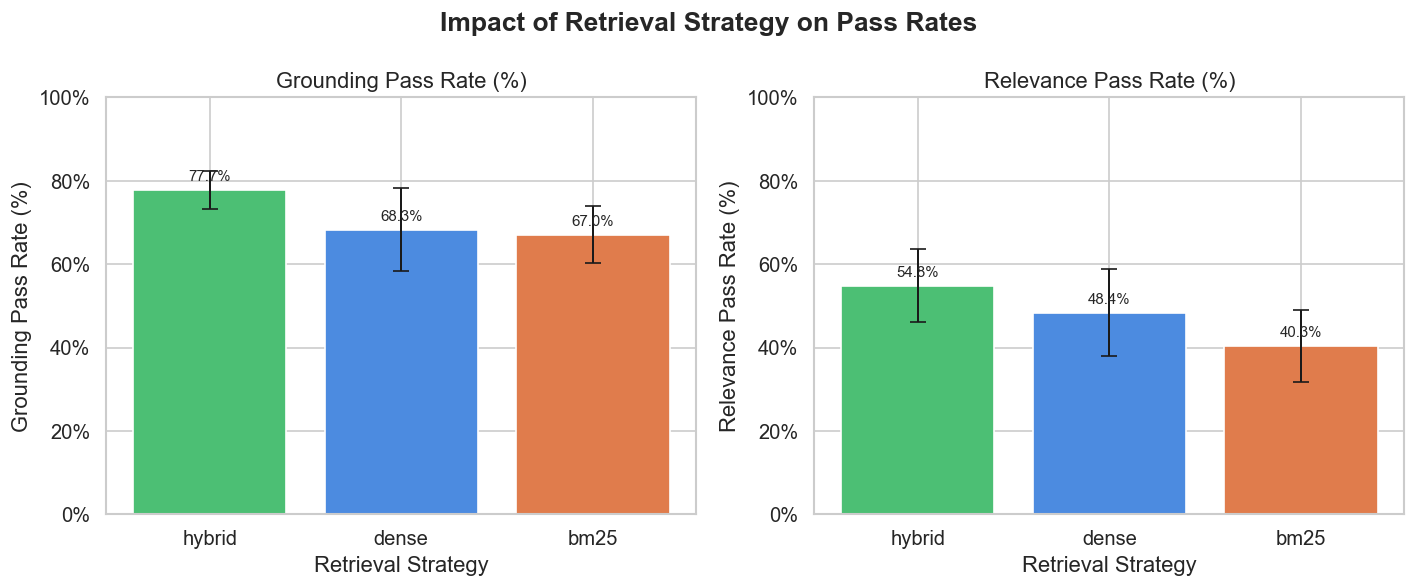

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

palette = {'dense': '#4C8BE0', 'bm25': '#E07C4C', 'hybrid': '#4CBF74'}

for ax, metric, title in zip(
    axes,
    ['grounding_rate', 'relevance_rate'],
    ['Grounding Pass Rate (%)', 'Relevance Pass Rate (%)']
):
    agg = (df.groupby('retrieval_strategy')[metric]
           .agg(['mean','std'])
           .reset_index()
           .sort_values('mean', ascending=False))
    bars = ax.bar(agg['retrieval_strategy'], agg['mean'],
                  yerr=agg['std'], capsize=5,
                  color=[palette[s] for s in agg['retrieval_strategy']],
                  edgecolor='white', error_kw={'linewidth':1.2})
    ax.set_xlabel('Retrieval Strategy')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))
    for bar, val in zip(bars, agg['mean']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

fig.suptitle('Impact of Retrieval Strategy on Pass Rates', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Effect of Embedding Model

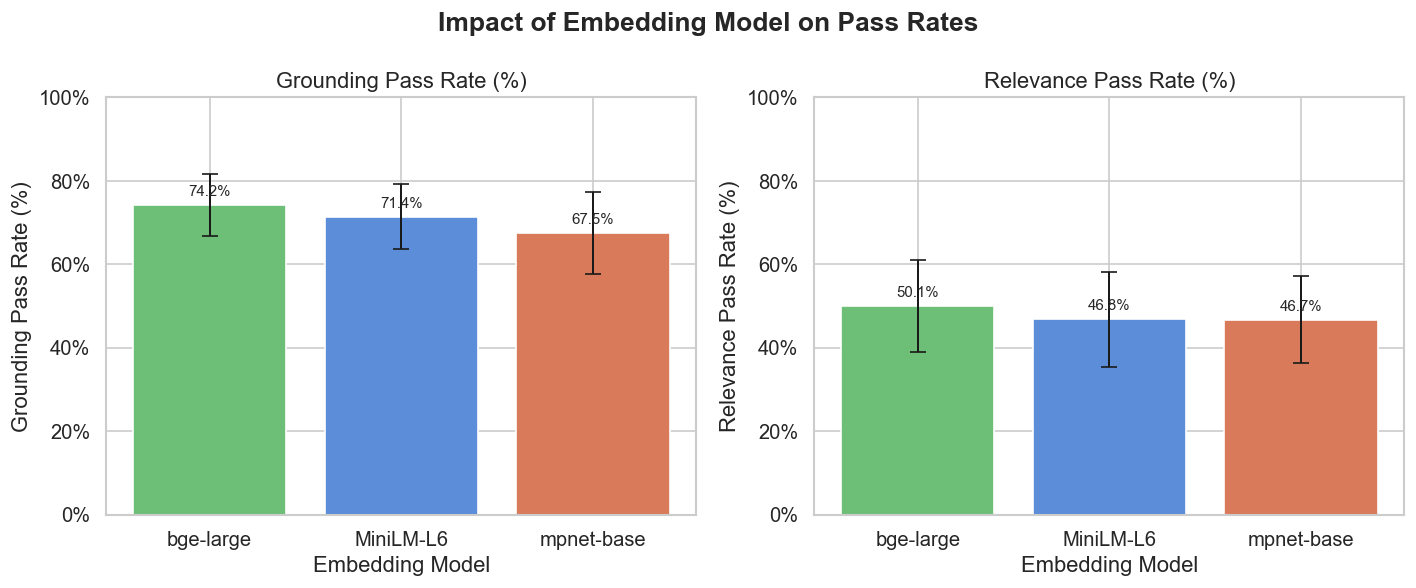

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

palette_emb = {'MiniLM-L6': '#5B8DD9', 'mpnet-base': '#D97B5B', 'bge-large': '#6DBF77'}

for ax, metric, title in zip(
    axes,
    ['grounding_rate', 'relevance_rate'],
    ['Grounding Pass Rate (%)', 'Relevance Pass Rate (%)']
):
    agg = (df.groupby('emb_short')[metric]
           .agg(['mean','std'])
           .reset_index()
           .sort_values('mean', ascending=False))
    bars = ax.bar(agg['emb_short'], agg['mean'],
                  yerr=agg['std'], capsize=5,
                  color=[palette_emb[s] for s in agg['emb_short']],
                  edgecolor='white', error_kw={'linewidth':1.2})
    ax.set_xlabel('Embedding Model')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))
    for bar, val in zip(bars, agg['mean']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

fig.suptitle('Impact of Embedding Model on Pass Rates', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Effect of Reranker and k

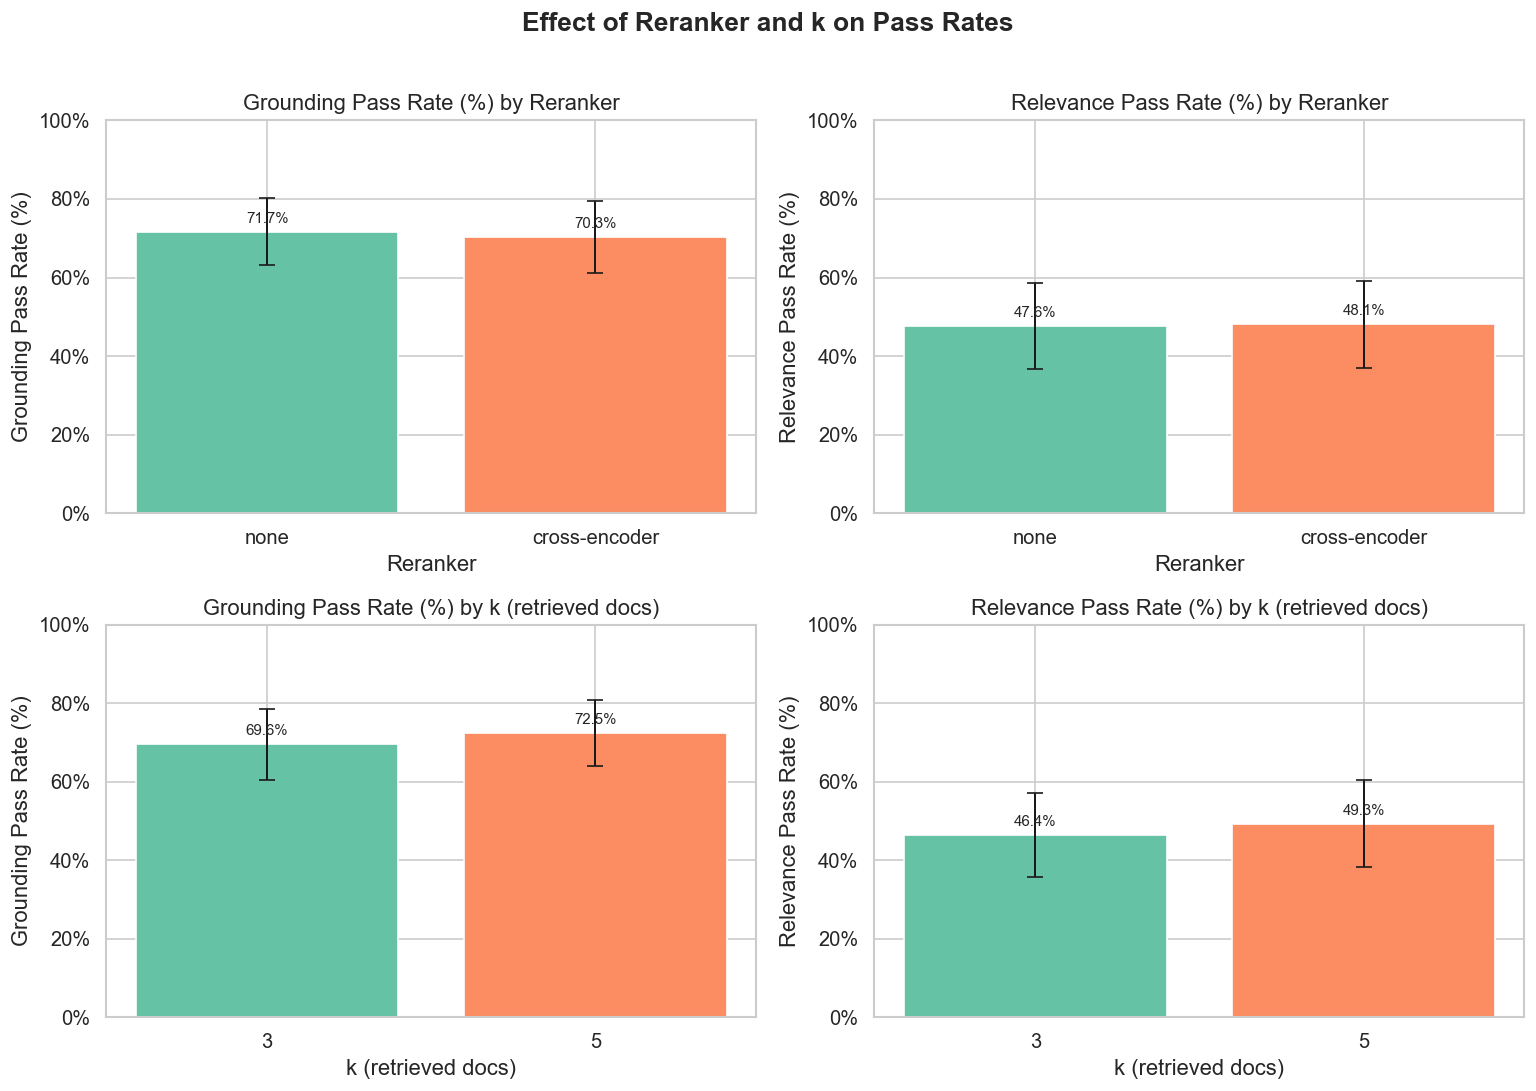

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

params = [
    ('reranker',   'Reranker',              ['none','cross-encoder']),
    ('k',          'k (retrieved docs)',     [3, 5]),
]

for row_idx, (param, xlabel, order) in enumerate(params):
    for col_idx, (metric, title) in enumerate([
        ('grounding_rate', 'Grounding Pass Rate (%)'),
        ('relevance_rate', 'Relevance Pass Rate (%)')
    ]):
        ax = axes[row_idx][col_idx]
        agg = (df.groupby(param)[metric]
               .agg(['mean','std'])
               .reindex(order)
               .reset_index())
        colors = sns.color_palette('Set2', len(order))
        bars = ax.bar([str(v) for v in agg[param]], agg['mean'],
                      yerr=agg['std'], capsize=5,
                      color=colors, edgecolor='white',
                      error_kw={'linewidth':1.2})
        ax.set_xlabel(xlabel)
        ax.set_ylabel(title)
        ax.set_title(f'{title} by {xlabel}')
        ax.set_ylim(0, 100)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))
        for bar, val in zip(bars, agg['mean']):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

fig.suptitle('Effect of Reranker and k on Pass Rates', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. Generator × Retrieval Strategy Heatmaps

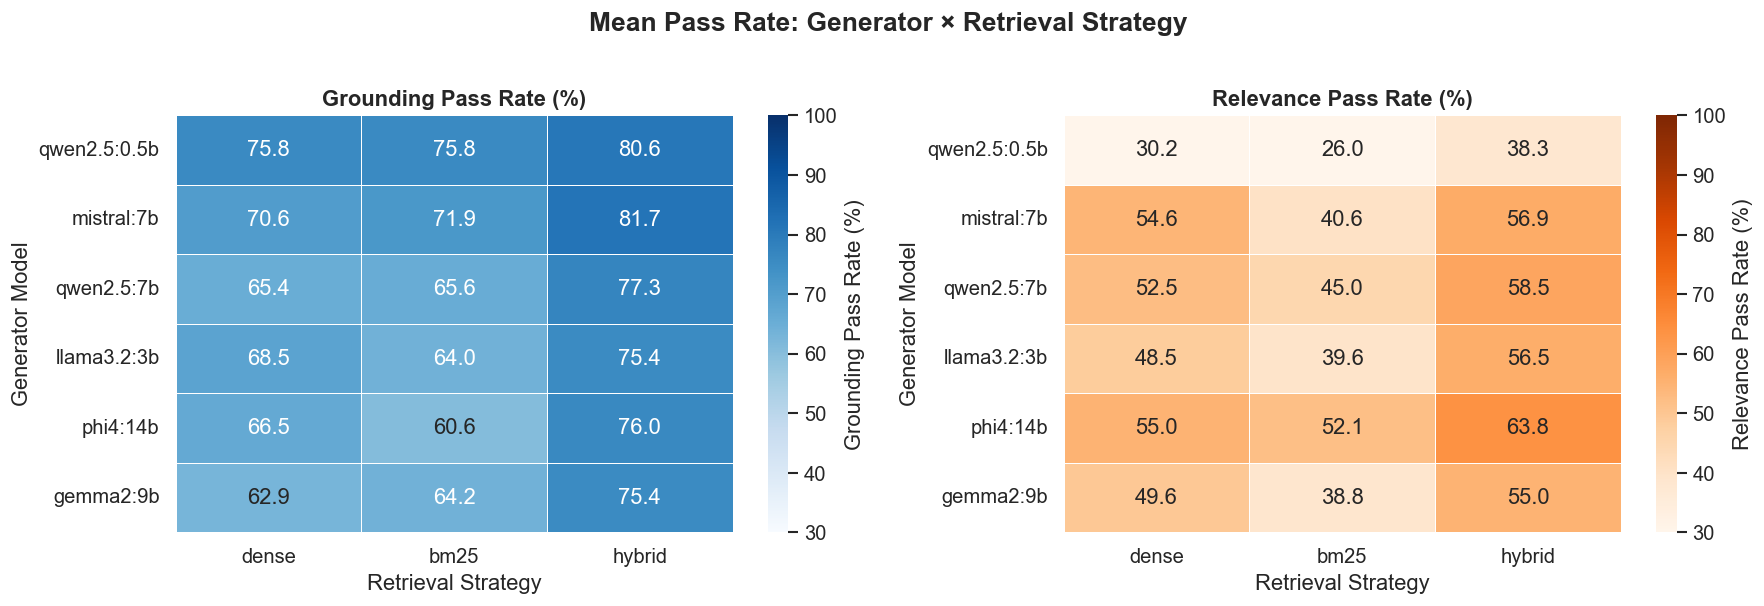

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Consistent model order (by overall grounding rate)
model_order = (df.groupby('generator_model')['grounding_rate']
               .mean().sort_values(ascending=False).index.tolist())
strat_order = ['dense', 'bm25', 'hybrid']

for ax, metric, title, cmap in zip(
    axes,
    ['grounding_rate', 'relevance_rate'],
    ['Grounding Pass Rate (%)', 'Relevance Pass Rate (%)'],
    ['Blues', 'Oranges']
):
    pivot = (df.groupby(['generator_model','retrieval_strategy'])[metric]
             .mean()
             .unstack('retrieval_strategy')
             .reindex(index=model_order, columns=strat_order))
    sns.heatmap(pivot, ax=ax, annot=True, fmt='.1f', cmap=cmap,
                vmin=30, vmax=100, linewidths=0.4, linecolor='white',
                cbar_kws={'label': title})
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Retrieval Strategy')
    ax.set_ylabel('Generator Model')

fig.suptitle('Mean Pass Rate: Generator × Retrieval Strategy', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Grouped Bar: All Parameters Side-by-Side

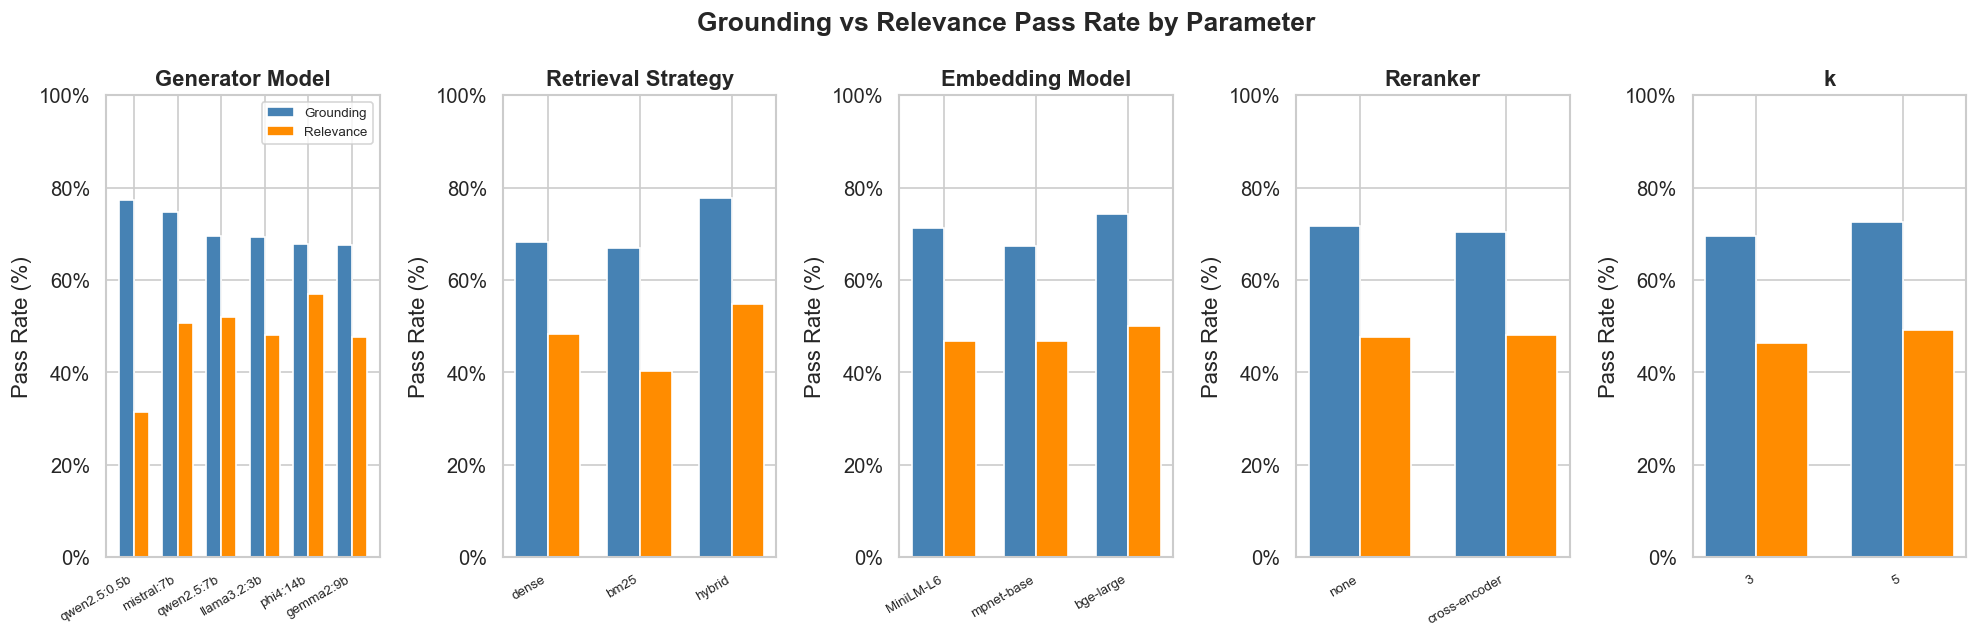

In [8]:
# Grouped bar comparing grounding vs relevance for each level of each parameter
params_info = [
    ('generator_model', 'Generator Model', model_order),
    ('retrieval_strategy', 'Retrieval Strategy', strat_order),
    ('emb_short', 'Embedding Model', ['MiniLM-L6','mpnet-base','bge-large']),
    ('reranker', 'Reranker', ['none','cross-encoder']),
    ('k', 'k', [3, 5]),
]

fig, axes = plt.subplots(1, len(params_info), figsize=(20, 5),
                         gridspec_kw={'wspace': 0.45})

for ax, (param, label, order) in zip(axes, params_info):
    agg = (df.groupby(param)[['grounding_rate','relevance_rate']]
           .mean()
           .reindex(order)
           .reset_index())
    x = np.arange(len(agg))
    w = 0.35
    b1 = ax.bar(x - w/2, agg['grounding_rate'], w,
                label='Grounding', color='steelblue', edgecolor='white')
    b2 = ax.bar(x + w/2, agg['relevance_rate'], w,
                label='Relevance', color='darkorange', edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels([str(v) for v in agg[param]], rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Pass Rate (%)')
    ax.set_title(label, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))
    if ax == axes[0]:
        ax.legend(fontsize=8)

fig.suptitle('Grounding vs Relevance Pass Rate by Parameter', fontweight='bold', y=1.02)
plt.show()

## 8. Grounding vs Relevance Scatter

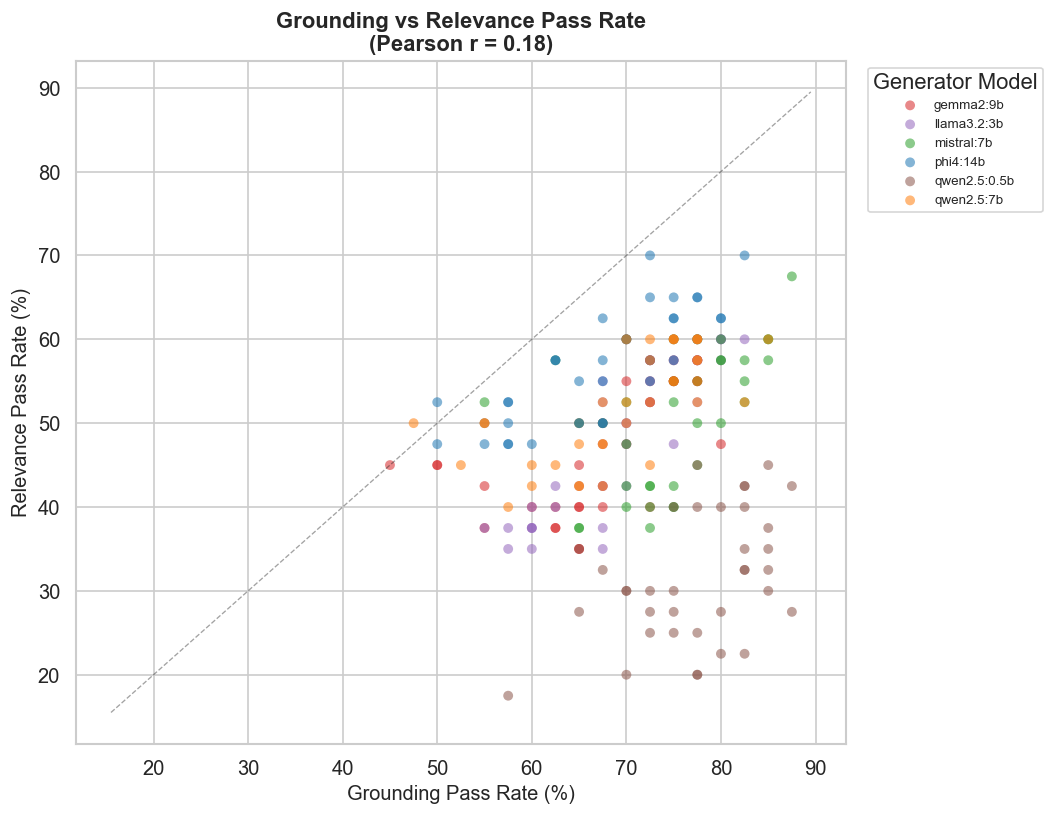

In [9]:
fig, ax = plt.subplots(figsize=(9, 7))

models = df['generator_model'].unique()
palette = dict(zip(models, sns.color_palette('tab10', len(models))))

for model, group in df.groupby('generator_model'):
    ax.scatter(group['grounding_rate'], group['relevance_rate'],
               color=palette[model], label=model, alpha=0.55, s=35, edgecolors='none')

# Overall correlation
corr = df['grounding_rate'].corr(df['relevance_rate'])
ax.set_xlabel('Grounding Pass Rate (%)', fontsize=12)
ax.set_ylabel('Relevance Pass Rate (%)', fontsize=12)
ax.set_title(f'Grounding vs Relevance Pass Rate\n(Pearson r = {corr:.2f})', fontweight='bold')
ax.legend(title='Generator Model', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

# Reference line (equal performance)
lo = min(df['grounding_rate'].min(), df['relevance_rate'].min()) - 2
hi = max(df['grounding_rate'].max(), df['relevance_rate'].max()) + 2
ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.8, alpha=0.4, label='y = x')

plt.tight_layout()
plt.show()

## 9. Top 20 Configurations

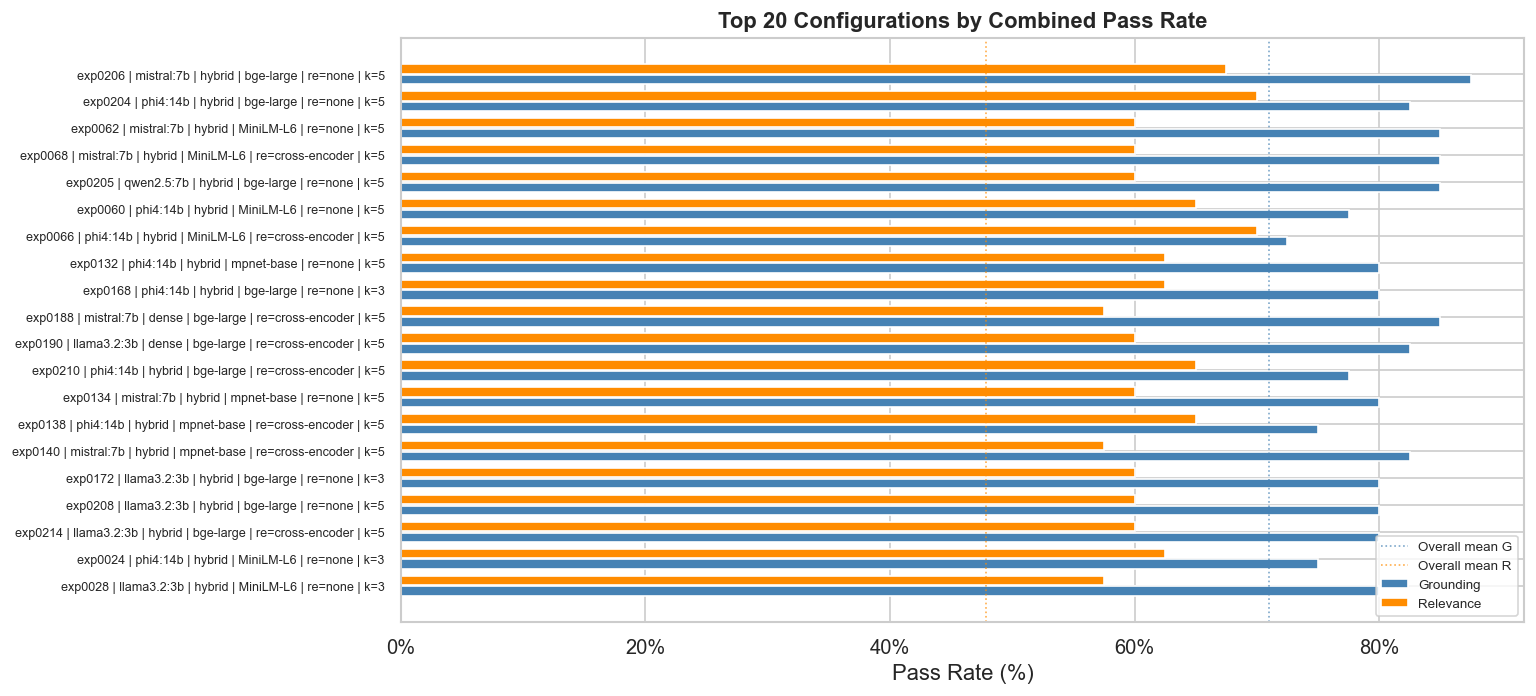


Top 10 configurations (table):


' exp_id generator_model retrieval_strategy  emb_short      reranker  k  grounding_rate  relevance_rate  combined_score\nexp0206      mistral:7b             hybrid  bge-large          none  5            87.5            67.5            77.5\nexp0204        phi4:14b             hybrid  bge-large          none  5            82.5            70.0            76.2\nexp0062      mistral:7b             hybrid  MiniLM-L6          none  5            85.0            60.0            72.5\nexp0068      mistral:7b             hybrid  MiniLM-L6 cross-encoder  5            85.0            60.0            72.5\nexp0205      qwen2.5:7b             hybrid  bge-large          none  5            85.0            60.0            72.5\nexp0060        phi4:14b             hybrid  MiniLM-L6          none  5            77.5            65.0            71.2\nexp0066        phi4:14b             hybrid  MiniLM-L6 cross-encoder  5            72.5            70.0            71.2\nexp0132        phi4:14b             hyb

In [10]:
# Combined score = equally weighted average of grounding and relevance rates
df['combined_score'] = (df['grounding_rate'] + df['relevance_rate']) / 2

top20 = (df.nlargest(20, 'combined_score')
         [['exp_id','generator_model','retrieval_strategy','emb_short',
           'reranker','k','grounding_rate','relevance_rate','combined_score']]
         .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(13, 6))

y = np.arange(len(top20))
labels = [
    f"{r['exp_id']} | {r['generator_model']} | {r['retrieval_strategy']} | "
    f"{r['emb_short']} | re={r['reranker']} | k={r['k']}"
    for _, r in top20.iterrows()
]

ax.barh(y + 0.2, top20['grounding_rate'], 0.35, label='Grounding', color='steelblue', edgecolor='white')
ax.barh(y - 0.2, top20['relevance_rate'],  0.35, label='Relevance',  color='darkorange', edgecolor='white')

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=7.5)
ax.invert_yaxis()
ax.set_xlabel('Pass Rate (%)')
ax.set_title('Top 20 Configurations by Combined Pass Rate', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))
ax.axvline(df['grounding_rate'].mean(), color='steelblue', linestyle=':', linewidth=1, alpha=0.7, label='Overall mean G')
ax.axvline(df['relevance_rate'].mean(), color='darkorange', linestyle=':', linewidth=1, alpha=0.7, label='Overall mean R')
ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

print('\nTop 10 configurations (table):')
top20.head(10).to_string(index=False, float_format='%.1f')

## 10. Parameter Importance (Variance Explained)

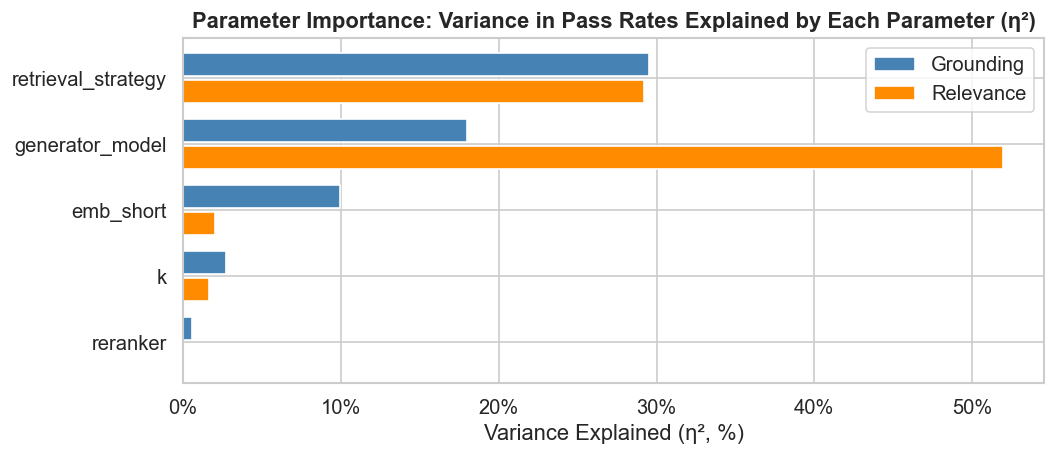

In [11]:
# Eta-squared: between-group variance / total variance for each parameter
params_to_test = ['generator_model', 'retrieval_strategy', 'emb_short', 'reranker', 'k']
results = []

for metric in ['grounding_rate', 'relevance_rate']:
    total_var = df[metric].var()
    for param in params_to_test:
        group_means = df.groupby(param)[metric].mean()
        group_counts = df.groupby(param)[metric].count()
        grand_mean = df[metric].mean()
        ss_between = ((group_means - grand_mean)**2 * group_counts).sum()
        ss_total = ((df[metric] - grand_mean)**2).sum()
        eta_sq = ss_between / ss_total
        results.append({'parameter': param, 'metric': metric, 'eta_squared': eta_sq})

imp_df = pd.DataFrame(results)
imp_pivot = imp_df.pivot(index='parameter', columns='metric', values='eta_squared').sort_values('grounding_rate', ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
y = np.arange(len(imp_pivot))
ax.barh(y + 0.2, imp_pivot['grounding_rate'] * 100, 0.35, label='Grounding', color='steelblue', edgecolor='white')
ax.barh(y - 0.2, imp_pivot['relevance_rate']  * 100, 0.35, label='Relevance',  color='darkorange', edgecolor='white')
ax.set_yticks(y)
ax.set_yticklabels(imp_pivot.index)
ax.set_xlabel('Variance Explained (η², %)')
ax.set_title('Parameter Importance: Variance in Pass Rates Explained by Each Parameter (η²)',
             fontweight='bold')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))
ax.legend()

plt.tight_layout()
plt.show()

## 11. Best Experiments: Grounding & Relevance

In [ ]:
cols = [
    'exp_id', 'generator_model', 'retrieval_strategy', 'emb_short', 'reranker', 'k',
    'grounding_passes', 'grounding_rate', 'relevance_passes', 'relevance_rate',
    'mean_grounding_score', 'mean_relevance_score',
]

best_grounding = df.loc[df['grounding_passes'].idxmax(), cols].rename('Best Grounding')
best_relevance = df.loc[df['relevance_passes'].idxmax(), cols].rename('Best Relevance')

table = pd.DataFrame([best_grounding, best_relevance])
table['grounding_rate'] = table['grounding_rate'].map('{:.1f}%'.format)
table['relevance_rate']  = table['relevance_rate'].map('{:.1f}%'.format)
table['mean_grounding_score'] = table['mean_grounding_score'].map('{:.3f}'.format)
table['mean_relevance_score'] = table['mean_relevance_score'].map('{:.3f}'.format)
table.index.name = 'Winner'

display(table.T.rename_axis('Parameter').style
        .set_caption('Experiments with the highest grounding passes and highest relevance passes')
        .set_table_styles([
            {'selector': 'caption', 'props': [('font-weight','bold'),('font-size','13px'),('text-align','left')]},
            {'selector': 'th', 'props': [('background-color','#f0f0f0'),('font-weight','bold')]},
        ])
)